This single notebook reproduces **every figure in the report** (Figures 1–8: national map,
study-area map, area/compactness histograms, density map, LS-LRSI score map, risk-status
map, correlation matrix) starting from the raw ACCIMT landslide inventory.

**How to use in Colab:**
1. Upload `shp_landslides.geojson` (or `shp_landslides.csv` / `kmz_landslides.geojson`) when prompted in Cell 2.
2. Runtime → Run all.
3. All figures are displayed inline and saved to `/content/figs/`.


## 1. Install dependencies (Colab does not have geopandas by default)

In [19]:
!pip install geopandas shapely --quiet


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Upload the landslide inventory file

In [20]:
import os

# Portable upload logic: prefer Colab upload when available, else use local `data_raw/` files
INPUT_FILE = None
try:
    from google.colab import files
    print("Running in Colab — please upload shp_landslides.geojson (recommended) or shp_landslides.csv")
    uploaded = files.upload()
    INPUT_FILE = list(uploaded.keys())[0]
    print(f"Using uploaded file: {INPUT_FILE}")
except Exception:
    # Local environment fallback: look for common filenames in data_raw/
    candidates = ['data_raw/shp_landslides.geojson', 'data_raw/shp_landslides.csv', 'data_raw/kmz_landslides.geojson']
    found = [p for p in candidates if os.path.exists(p)]
    if found:
        INPUT_FILE = found[0]
        print(f"Found local file: {INPUT_FILE}")
    else:
        print("Not in Colab and no local file found in data_raw/. Please place shp_landslides.geojson in data_raw/ or set INPUT_FILE manually.")
        INPUT_FILE = 'data_raw/shp_landslides.geojson'
        print(f"Defaulting INPUT_FILE to: {INPUT_FILE}")

Found local file: data_raw/shp_landslides.geojson


## 3. Imports and study-area / grid parameters

In [21]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import box
from shapely import wkt
import os

os.makedirs('/content/figs', exist_ok=True)

STUDY_BBOX = (81.05, 6.95, 81.20, 7.10)   # lon_min, lat_min, lon_max, lat_max — Passara DSD
CELL_SIZE_M = 1000.0
UTM_CRS = 32644   # UTM Zone 44N (Sri Lanka)

def add_north_arrow(ax, x=0.93, y=0.90, size=0.05):
    ax.annotate('N', xy=(x, y), xytext=(x, y-size),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=8),
                ha='center', va='center', fontsize=11, fontweight='bold')

def add_scale_bar(ax, lat_for_km=7.0, length_km=2, location=(0.06,0.05)):
    deg_per_km = 1/(111.32*np.cos(np.radians(lat_for_km)))
    bar_len_deg = length_km*deg_per_km
    x0, y0 = location
    xdata0 = ax.get_xlim()[0] + x0*(ax.get_xlim()[1]-ax.get_xlim()[0])
    ydata0 = ax.get_ylim()[0] + y0*(ax.get_ylim()[1]-ax.get_ylim()[0])
    ax.plot([xdata0, xdata0+bar_len_deg], [ydata0, ydata0], color='black', lw=3)
    ax.text(xdata0+bar_len_deg/2, ydata0+0.01*(ax.get_ylim()[1]-ax.get_ylim()[0]),
            f'{length_km} km', ha='center', va='bottom', fontsize=8)

def add_credit(ax, text):
    ax.text(0.01, -0.11, text, transform=ax.transAxes, fontsize=7, style='italic')

## 4. Load inventory (handles .geojson or .csv-with-WKT) and engineer indicators

In [22]:
if INPUT_FILE.endswith('.geojson') or INPUT_FILE.endswith('.json'):
    gdf = gpd.read_file(INPUT_FILE)
elif INPUT_FILE.endswith('.csv'):
    df = pd.read_csv(INPUT_FILE)
    geom_col = 'geometry_wkt' if 'geometry_wkt' in df.columns else 'geometry'
    df['geometry'] = df[geom_col].apply(wkt.loads)
    gdf = gpd.GeoDataFrame(df, geometry='geometry')
else:
    raise ValueError("Unsupported file type — upload .geojson or .csv")

gdf = gdf.set_crs(4326, allow_override=True)
gdf_utm = gdf.to_crs(UTM_CRS)

gdf['area_m2'] = gdf_utm.area
gdf['perimeter_m'] = gdf_utm.length
gdf['compactness'] = (4*np.pi*gdf['area_m2']) / (gdf['perimeter_m']**2)

cent_geo = gdf.geometry.to_crs(4326).centroid
gdf['lon'] = cent_geo.x
gdf['lat'] = cent_geo.y

print(f"Total landslides loaded: {len(gdf)}")
gdf[['area_m2','perimeter_m','compactness']].describe()

Total landslides loaded: 4225


C:\Users\isuru.sanjana\AppData\Local\Temp\ipykernel_46292\1299785559.py:18: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  cent_geo = gdf.geometry.to_crs(4326).centroid


,area_m2,perimeter_m,compactness
count,4.225000e+03,4225.000000,4225.000000
mean,7.404178e+03,455.384327,0.503560
std,2.559350e+04,675.964957,0.227552
min,5.417242e+00,11.586858,0.031363
25%,1.384455e+03,168.385488,0.322502
50%,3.044116e+03,279.122186,0.498728
75%,6.416253e+03,484.259367,0.684784
max,1.283126e+06,17103.393966,0.974468


## Figure 1 — National distribution + study-area box

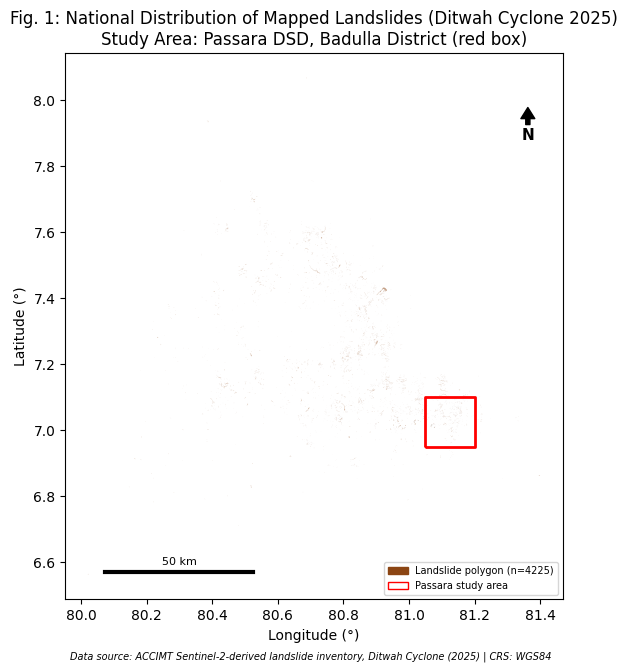

In [23]:
fig, ax = plt.subplots(figsize=(6,7))
gdf.plot(ax=ax, markersize=1, color='#8B4513', alpha=0.5)
study_box = box(*STUDY_BBOX)
gpd.GeoSeries([study_box], crs=4326).boundary.plot(ax=ax, color='red', linewidth=2)
ax.set_title('Fig. 1: National Distribution of Mapped Landslides (Ditwah Cyclone 2025)\nStudy Area: Passara DSD, Badulla District (red box)')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
add_north_arrow(ax)
add_scale_bar(ax, lat_for_km=7.3, length_km=50, location=(0.08,0.05))
ax.legend(handles=[mpatches.Patch(color='#8B4513', label=f'Landslide polygon (n={len(gdf)})'),
                    mpatches.Patch(edgecolor='red', facecolor='none', label='Passara study area')],
          loc='lower right', fontsize=7)
add_credit(ax, 'Data source: ACCIMT Sentinel-2-derived landslide inventory, Ditwah Cyclone (2025) | CRS: WGS84')
plt.tight_layout(); plt.savefig('/content/figs/fig1_national_overview.png', dpi=150); plt.show()

## 5. Subset the Passara study area

In [24]:
lon_min, lat_min, lon_max, lat_max = STUDY_BBOX
sub = gdf[(gdf.lon.between(lon_min, lon_max)) & (gdf.lat.between(lat_min, lat_max))].copy()
sub_utm = sub.set_crs(4326, allow_override=True).to_crs(UTM_CRS)
print(f"Study-area landslides: {len(sub)}")

Study-area landslides: 698


## Figure 2 — Study-area landslide polygons

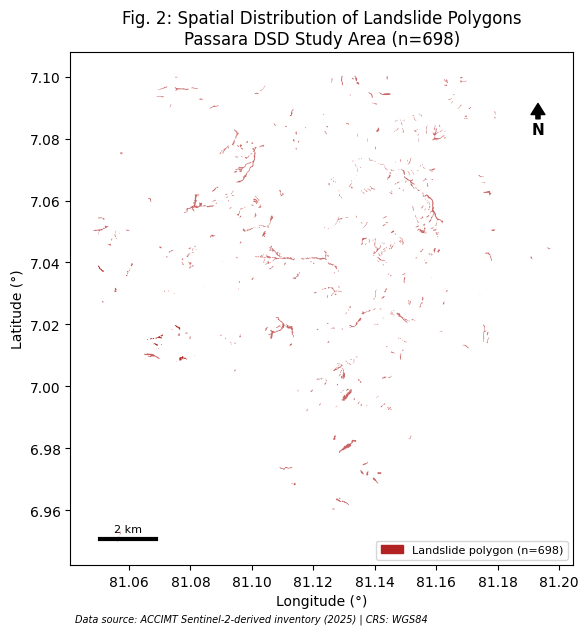

In [25]:
fig, ax = plt.subplots(figsize=(6,6.3))
sub.plot(ax=ax, color='#B22222', markersize=8, alpha=0.7)
ax.set_title(f'Fig. 2: Spatial Distribution of Landslide Polygons\nPassara DSD Study Area (n={len(sub)})')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
add_north_arrow(ax)
add_scale_bar(ax, lat_for_km=7.0, length_km=2, location=(0.06,0.05))
ax.legend(handles=[mpatches.Patch(color='#B22222', label=f'Landslide polygon (n={len(sub)})')], loc='lower right', fontsize=8)
add_credit(ax, 'Data source: ACCIMT Sentinel-2-derived inventory (2025) | CRS: WGS84')
plt.tight_layout(); plt.savefig('/content/figs/fig2_study_area_landslides.png', dpi=150); plt.show()

## Figure 3 — Landslide area distribution (log scale)

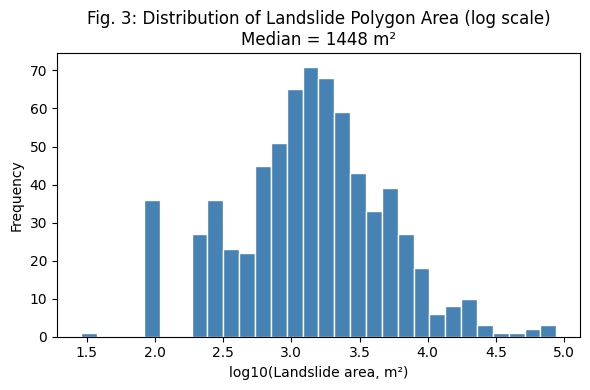

In [26]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(np.log10(sub['area_m2']), bins=30, color='#4682B4', edgecolor='white')
ax.set_xlabel('log10(Landslide area, m²)'); ax.set_ylabel('Frequency')
ax.set_title(f"Fig. 3: Distribution of Landslide Polygon Area (log scale)\nMedian = {sub['area_m2'].median():.0f} m²")
plt.tight_layout(); plt.savefig('/content/figs/fig3_area_distribution.png', dpi=150); plt.show()

## Figure 4 — Compactness (shape) distribution

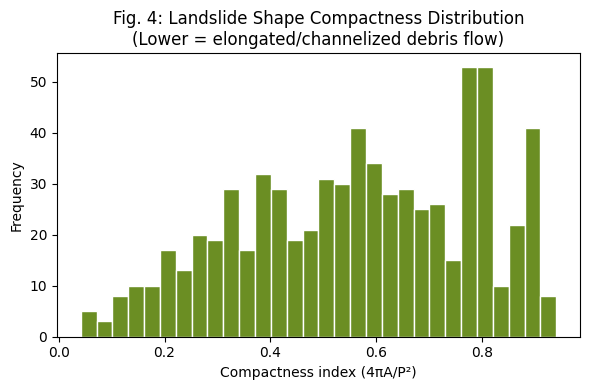

In [27]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(sub['compactness'], bins=30, color='#6B8E23', edgecolor='white')
ax.set_xlabel('Compactness index (4πA/P²)'); ax.set_ylabel('Frequency')
ax.set_title('Fig. 4: Landslide Shape Compactness Distribution\n(Lower = elongated/channelized debris flow)')
plt.tight_layout(); plt.savefig('/content/figs/fig4_compactness_distribution.png', dpi=150); plt.show()

## 6. Build 1 km grid, aggregate, normalise, compute LS-LRSI

In [28]:
minx, miny, maxx, maxy = sub_utm.total_bounds
pad = 500
minx -= pad; miny -= pad; maxx += pad; maxy += pad
nx = int(np.ceil((maxx-minx)/CELL_SIZE_M)); ny = int(np.ceil((maxy-miny)/CELL_SIZE_M))

cells_list = [{'grid_id': f'{i}_{j}', 'geometry': box(minx+i*CELL_SIZE_M, miny+j*CELL_SIZE_M,
                                                       minx+(i+1)*CELL_SIZE_M, miny+(j+1)*CELL_SIZE_M)}
              for i in range(nx) for j in range(ny)]
grid = gpd.GeoDataFrame(cells_list, crs=UTM_CRS)

joined = gpd.sjoin(sub_utm, grid, predicate='within', how='left')
agg = joined.groupby('grid_id').agg(n_landslides=('area_m2','count'),
                                     total_area_m2=('area_m2','sum'),
                                     mean_compactness=('compactness','mean')).reset_index()
grid = grid.merge(agg, on='grid_id', how='left')
grid[['n_landslides','total_area_m2']] = grid[['n_landslides','total_area_m2']].fillna(0)
grid['mean_compactness'] = grid['mean_compactness'].fillna(grid['mean_compactness'].median())
grid['density_km2'] = grid['n_landslides'] / (CELL_SIZE_M*CELL_SIZE_M/1e6)

def minmax(s): return (s - s.min()) / (s.max() - s.min() + 1e-9)
grid['HLD_norm']  = minmax(grid['n_landslides'])
grid['MAG_norm']  = minmax(np.log1p(grid['total_area_m2']))
grid['CHAN_norm'] = 1 - minmax(grid['mean_compactness'])

W_HLD, W_MAG, W_CHAN = 0.50, 0.30, 0.20
grid['LS_LRSI'] = (W_HLD*grid['HLD_norm'] + W_MAG*grid['MAG_norm'] + W_CHAN*grid['CHAN_norm']) * 100

qs = grid['LS_LRSI'].quantile([0.50, 0.75, 0.90]).values
def classify(v):
    if v <= qs[0]: return 'Low'
    elif v <= qs[1]: return 'Medium'
    elif v <= qs[2]: return 'High'
    else: return 'Very High'
grid['risk_class'] = grid['LS_LRSI'].apply(classify)
grid_wgs = grid.to_crs(4326)
print(grid['risk_class'].value_counts())

risk_class
Low          204
High          48
Medium        39
Very High     33
Name: count, dtype: int64


## Figure 5 — Historical landslide density map (with landslides overlaid)

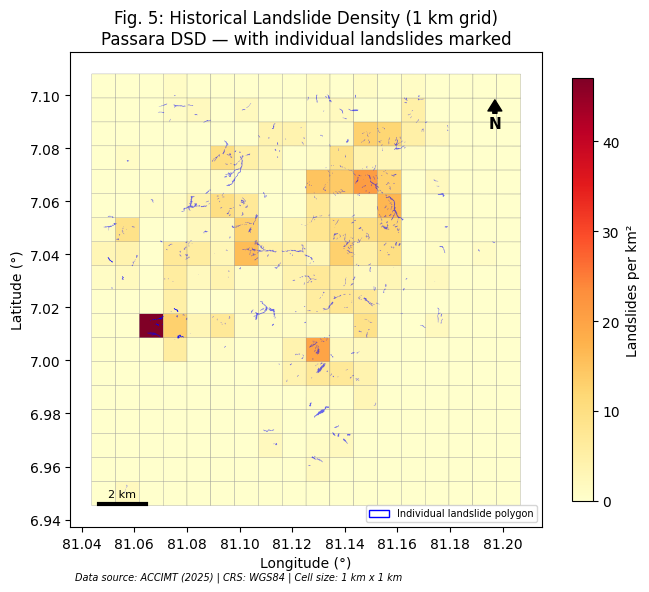

In [29]:
fig, ax = plt.subplots(figsize=(6.8,6.5))
grid_wgs.plot(column='density_km2', ax=ax, cmap='YlOrRd', legend=True,
              legend_kwds={'label':'Landslides per km²','shrink':0.7}, edgecolor='grey', linewidth=0.2)
sub.plot(ax=ax, color='blue', markersize=3, alpha=0.6)
ax.set_title('Fig. 5: Historical Landslide Density (1 km grid)\nPassara DSD — with individual landslides marked')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
add_north_arrow(ax, x=0.90)
add_scale_bar(ax, lat_for_km=7.0, length_km=2, location=(0.06,0.05))
ax.legend(handles=[mpatches.Patch(facecolor='none', edgecolor='blue', label='Individual landslide polygon')], loc='lower right', fontsize=7)
add_credit(ax, 'Data source: ACCIMT (2025) | CRS: WGS84 | Cell size: 1 km x 1 km')
plt.tight_layout(); plt.savefig('/content/figs/fig5_density_grid.png', dpi=150); plt.show()

## Figure 6 — LS-LRSI score map (with landslides overlaid)

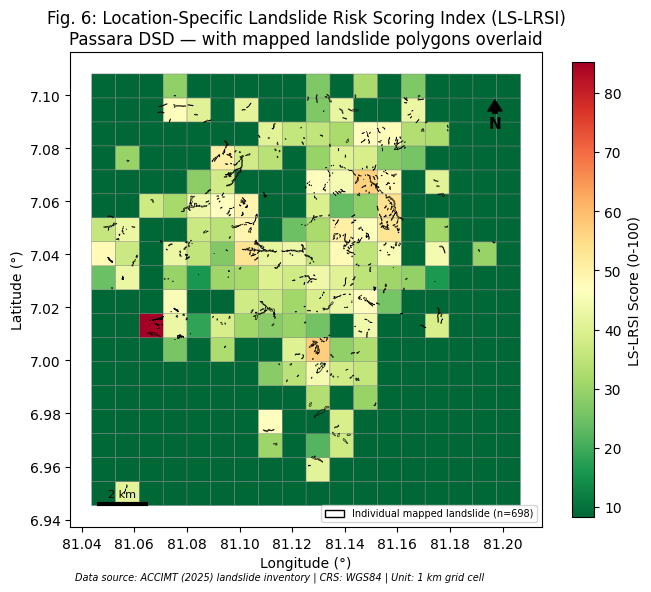

In [30]:
fig, ax = plt.subplots(figsize=(6.8,6.8))
grid_wgs.plot(column='LS_LRSI', ax=ax, cmap='RdYlGn_r', legend=True,
              legend_kwds={'label':'LS-LRSI Score (0-100)','shrink':0.7}, edgecolor='grey', linewidth=0.3)
sub.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.4, markersize=1)
ax.set_title('Fig. 6: Location-Specific Landslide Risk Scoring Index (LS-LRSI)\nPassara DSD — with mapped landslide polygons overlaid')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
add_north_arrow(ax, x=0.90)
add_scale_bar(ax, lat_for_km=7.0, length_km=2, location=(0.06,0.05))
ax.legend(handles=[mpatches.Patch(facecolor='none', edgecolor='black', label=f'Individual mapped landslide (n={len(sub)})')], loc='lower right', fontsize=7)
add_credit(ax, 'Data source: ACCIMT (2025) landslide inventory | CRS: WGS84 | Unit: 1 km grid cell')
plt.tight_layout(); plt.savefig('/content/figs/fig6_lslrsi_map.png', dpi=150); plt.show()

## Figure 7 — Risk-status classification map (with landslides overlaid + top cell labelled)

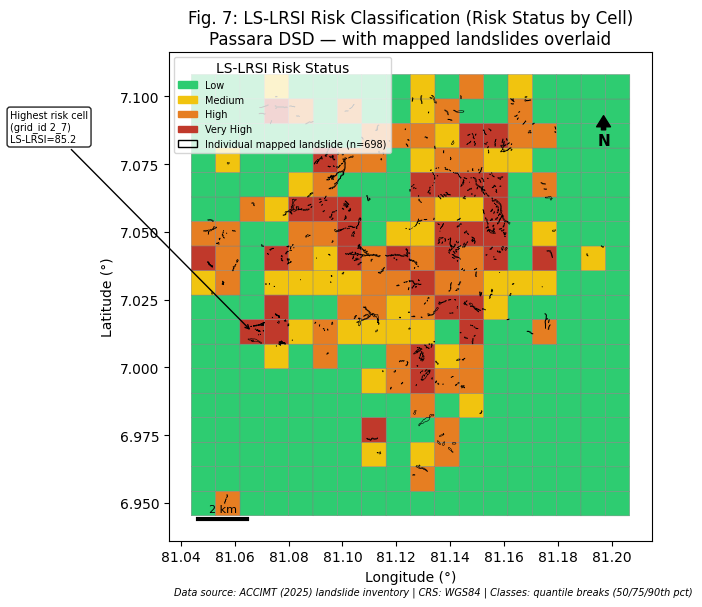

In [31]:
cls_colors = {'Low':'#2ecc71','Medium':'#f1c40f','High':'#e67e22','Very High':'#c0392b'}
fig, ax = plt.subplots(figsize=(6.8,6.8))
for cls, color in cls_colors.items():
    s = grid_wgs[grid_wgs.risk_class == cls]
    if len(s): s.plot(ax=ax, color=color, edgecolor='grey', linewidth=0.3)
sub.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.4, markersize=1)

top_cell = grid_wgs.loc[grid_wgs['LS_LRSI'].idxmax()]
cx, cy = top_cell.geometry.centroid.x, top_cell.geometry.centroid.y
ax.annotate(f"Highest risk cell\n(grid_id {top_cell['grid_id']})\nLS-LRSI={top_cell['LS_LRSI']:.1f}",
            xy=(cx,cy), xytext=(cx-0.09, cy+0.07),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=7,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', alpha=0.85))

handles = [mpatches.Patch(color=c, label=l) for l,c in cls_colors.items()]
handles.append(mpatches.Patch(facecolor='none', edgecolor='black', label=f'Individual mapped landslide (n={len(sub)})'))
ax.legend(handles=handles, title='LS-LRSI Risk Status', loc='upper left', fontsize=7)
ax.set_title('Fig. 7: LS-LRSI Risk Classification (Risk Status by Cell)\nPassara DSD — with mapped landslides overlaid')
ax.set_xlabel('Longitude (°)'); ax.set_ylabel('Latitude (°)')
add_north_arrow(ax, x=0.90, y=0.87)
add_scale_bar(ax, lat_for_km=7.0, length_km=2, location=(0.06,0.04))
add_credit(ax, 'Data source: ACCIMT (2025) landslide inventory | CRS: WGS84 | Classes: quantile breaks (50/75/90th pct)')
plt.tight_layout(); plt.savefig('/content/figs/fig7_risk_classes.png', dpi=150); plt.show()

## Figure 8 — Indicator correlation matrix

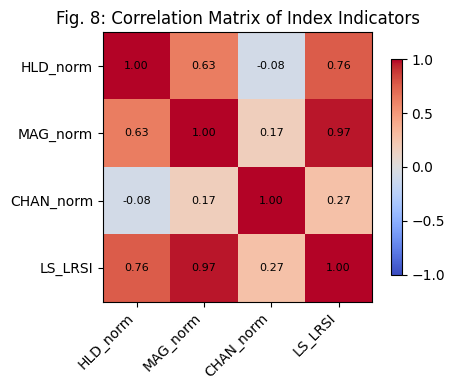

In [32]:
corr = grid[['HLD_norm','MAG_norm','CHAN_norm','LS_LRSI']].corr()
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.columns))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
plt.colorbar(im, shrink=0.8)
ax.set_title('Fig. 8: Correlation Matrix of Index Indicators')
plt.tight_layout(); plt.savefig('/content/figs/fig8_correlation.png', dpi=150); plt.show()

## 7. Export scored data + download all figures

In [33]:
grid.to_file('/content/passara_grid_1km_index.geojson', driver='GeoJSON')
grid.drop(columns='geometry').to_csv('/content/passara_grid_1km_index.csv', index=False)
sub.to_file('/content/passara_landslides.geojson', driver='GeoJSON')

import shutil
shutil.make_archive('/content/LS-LRSI_outputs', 'zip', '/content/figs')
print("Done. Files in /content/: passara_grid_1km_index.geojson, .csv, passara_landslides.geojson, LS-LRSI_outputs.zip")

# Uncomment to download in Colab:
# from google.colab import files
# files.download('/content/LS-LRSI_outputs.zip')
# files.download('/content/passara_grid_1km_index.geojson')

Done. Files in /content/: passara_grid_1km_index.geojson, .csv, passara_landslides.geojson, LS-LRSI_outputs.zip
